# Домашнее задание 3 по теме «Модели ARMA»

In [2]:
# импортирую библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error


Загрузка данных

In [3]:
# загружаю ряд
airlines = pd.read_csv("international-airline-passengers.csv")

# переименовываю колонки
airlines.columns = ["Date", "Count"]

# беру сам временной ряд
series = airlines["Count"]


Смотрю на ряд

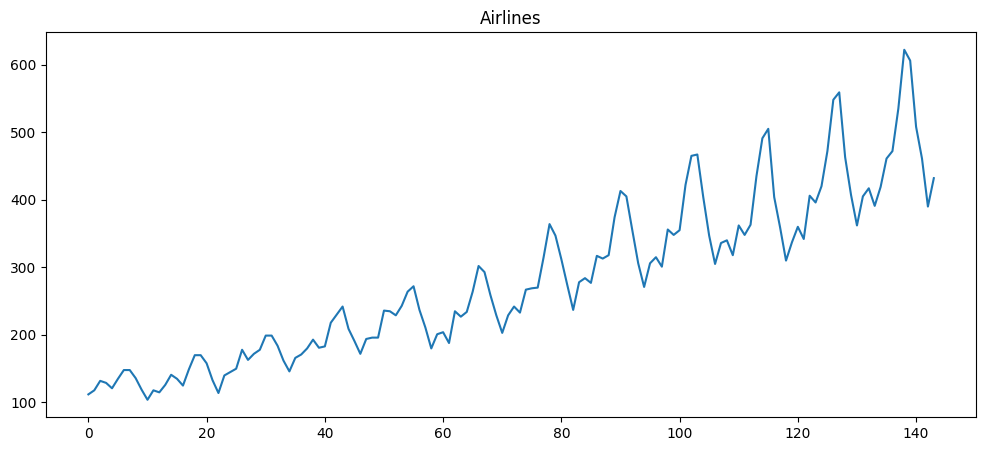

In [4]:
# строю график ряда
plt.figure(figsize=(12, 5))
plt.plot(series)
plt.title("Airlines")
plt.show()


Проверяю стационарность

In [5]:
# функция для теста Дики-Фуллера
def adf_test(series, name=""):
    result = adfuller(series)
    print(name)
    print("stat:", result[0])
    print("p-value:", result[1])
    print("-" * 30)

# проверяю исходный ряд
adf_test(series, "Airlines")


Airlines
stat: 0.8153688792060498
p-value: 0.991880243437641
------------------------------


Ряд нестационарный, делаю дифференцирование.

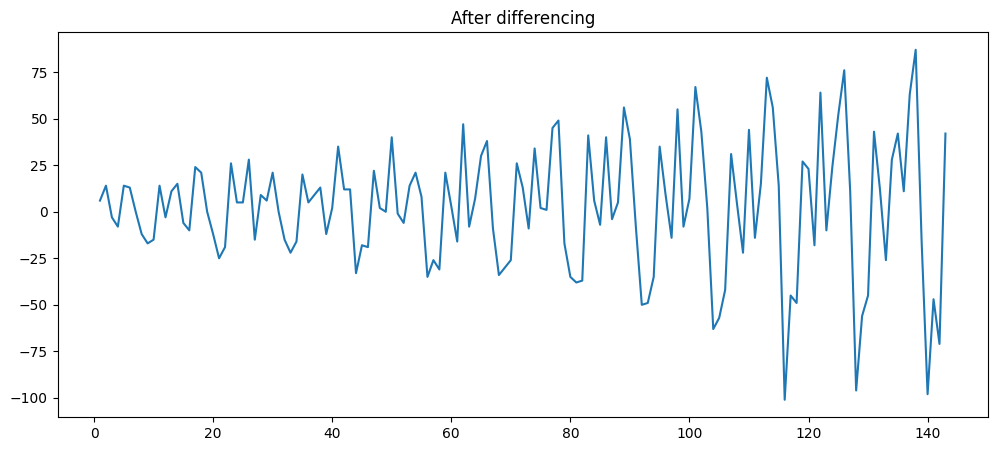

Airlines diff
stat: -2.8292668241700047
p-value: 0.05421329028382478
------------------------------


In [6]:
# делаю дифференцирование
series_diff = series.diff().dropna()

# строю график после дифференцирования
plt.figure(figsize=(12, 5))
plt.plot(series_diff)
plt.title("After differencing")
plt.show()

# снова проверяю стационарность
adf_test(series_diff, "Airlines diff")


Разделение на train и test

In [7]:
# делю ряд на train и test
train_size = int(len(series) * 0.8)
train = series[:train_size]
test = series[train_size:]


Подбор параметров

In [8]:
# задаю варианты параметров p, d, q
p = range(0, 3)
d = range(0, 3)
q = range(0, 3)

# все комбинации параметров
pdq = list(itertools.product(p, d, q))

# сохраняю лучший результат
best_score = float("inf")
best_order = None

# перебираю параметры
for order in pdq:
    try:
        # строю модель
        model = ARIMA(train, order=order)
        model_fit = model.fit()

        # делаю прогноз
        predictions = model_fit.forecast(steps=len(test))

        # считаю ошибку
        mse = mean_squared_error(test, predictions)

        # сохраняю лучший результат
        if mse < best_score:
            best_score = mse
            best_order = order

    except:
        continue

print("Best order:", best_order)
print("Best MSE:", best_score)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Best order: (2, 1, 2)
Best MSE: 6808.397034418323


Строю модель

In [9]:
# строю модель с лучшими параметрами
model = ARIMA(train, order=best_order)
model_fit = model.fit()

# делаю прогноз
predictions = model_fit.forecast(steps=len(test))


Сравнение

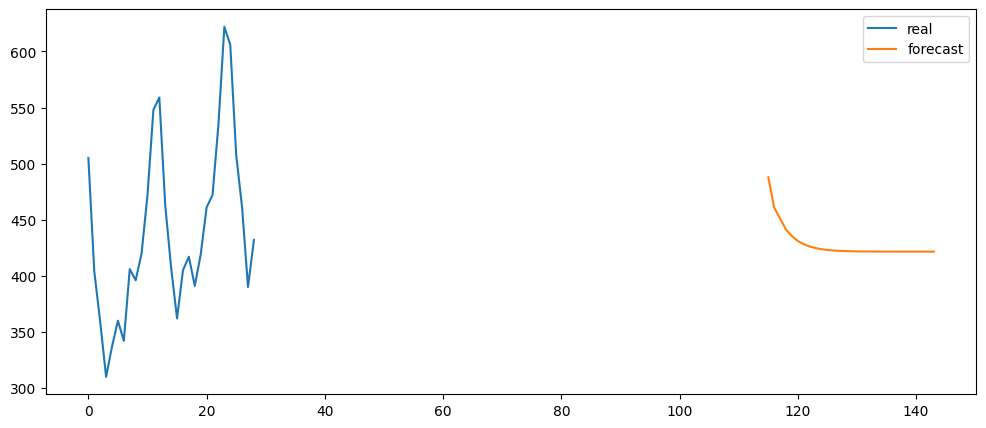

In [10]:
# сравниваю прогноз и реальные значения
plt.figure(figsize=(12, 5))
plt.plot(test.values, label="real")
plt.plot(predictions, label="forecast")
plt.legend()
plt.show()


Остатки

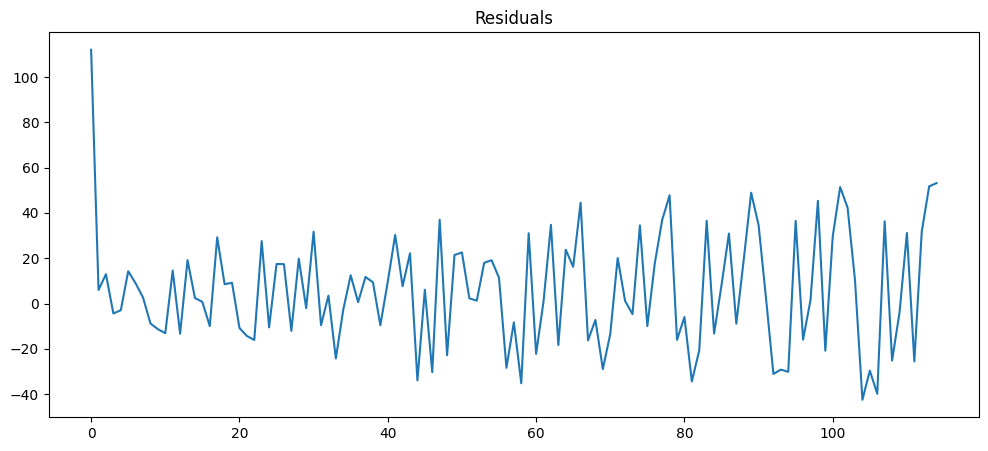

In [11]:
# беру остатки
residuals = model_fit.resid

# строю график остатков
plt.figure(figsize=(12, 5))
plt.plot(residuals)
plt.title("Residuals")
plt.show()


 Вывод


Построила модель ARIMA для ряда Airlines, подобрала параметры, сделала прогноз и построила график остатков.
